<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import folium
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/preprocessed_dataset.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head()

,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,1,Murder or Manslaughter,Male,18,White,Male,0.0,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,3,Murder or Manslaughter,Male,27,White,Male,0.0,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,1,Murder or Manslaughter,Male,42,Black,Male,18.0,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,6,Murder or Manslaughter,Male,44,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,1,Murder or Manslaughter,Female,15,White,Male,20.0,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


EDA (Exploratory Data Analysis)

<ipython-input-4-372c2f28047c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")


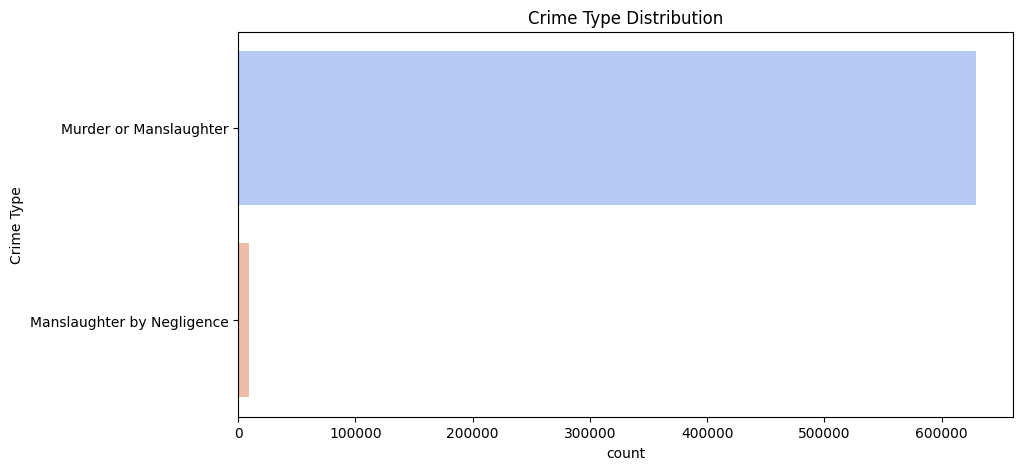

In [4]:
# Distribution of homicide crime types
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")
plt.title("Crime Type Distribution")
plt.show()

<ipython-input-5-b69b9ed5197d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")


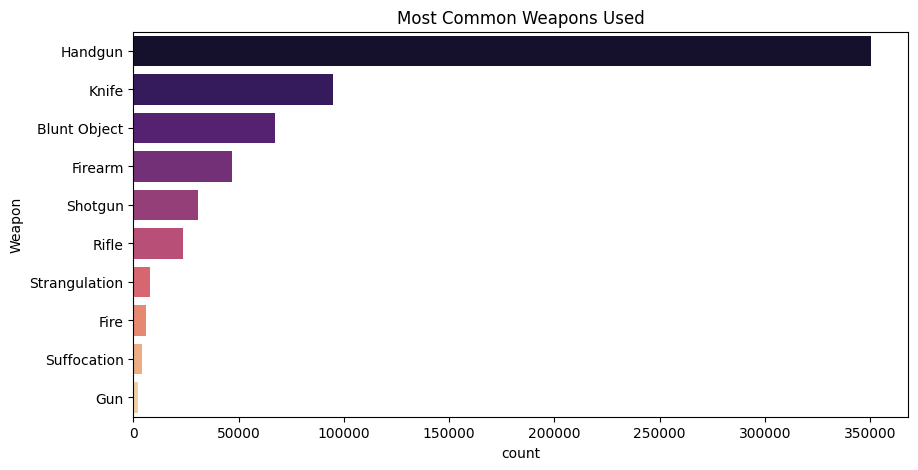

In [5]:
# Plotting most common weapons used
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")
plt.title("Most Common Weapons Used")
plt.show()

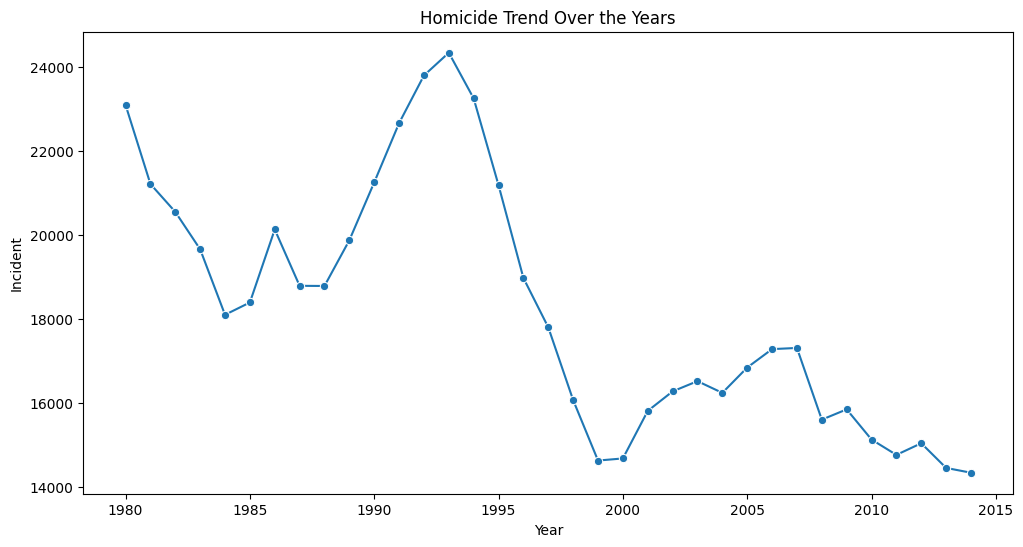

In [6]:
# Identify homicide trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Incident", data=homicide_data.groupby("Year")["Incident"].count().reset_index(), marker="o")
plt.title("Homicide Trend Over the Years")
plt.show()

In [7]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age","Victim Age","Incident"])

In [8]:
# View data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,Murder or Manslaughter,Male,White,Male,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,Murder or Manslaughter,Male,White,Male,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,Murder or Manslaughter,Male,Black,Male,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,Murder or Manslaughter,Male,White,Male,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,Murder or Manslaughter,Female,White,Male,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


In [9]:
# Check null values
homicide_data.isnull().sum()

,0
City,0
State,0
Year,0
Month,0
Crime Type,0
Victim Sex,0
Victim Race,0
Perpetrator Sex,0
Perpetrator Race,0
Relationship,0


In [10]:
# Getting a sample percentage of data to preprocess
data_percentage = 0.5
homicide_data = homicide_data.sample(frac=data_percentage, random_state=42)

In [11]:
# Replacing NA with Unknown to identify null columns
homicide_data.replace( np.nan,"Unknown", inplace=True)

In [12]:
# View data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
484984,Baltimore city,Maryland,1996,8,Murder or Manslaughter,Male,Black,Male,White,Acquaintance,Handgun,0,0,Senior (50+),Unknown
608445,Essex,New Jersey,2013,9,Murder or Manslaughter,Male,White,Male,Black,Stranger,Handgun,0,0,Young Adult (20-29),Teen (13-19)
417612,Wayne,Michigan,1997,11,Murder or Manslaughter,Male,Black,Male,White,Acquaintance,Firearm,0,0,Young Adult (20-29),Unknown
372692,Dade,Florida,1995,12,Murder or Manslaughter,Male,White,Male,Black,Son,Blunt Object,0,0,Child (0-12),Adult (30-49)
402028,Los Angeles,California,2002,11,Murder or Manslaughter,Male,White,Male,White,Stranger,Handgun,0,0,Teen (13-19),Teen (13-19)


In [13]:
# View dataset info
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319227 entries, 484984 to 190407
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   City                   319227 non-null  object
 1   State                  319227 non-null  object
 2   Year                   319227 non-null  int64 
 3   Month                  319227 non-null  int64 
 4   Crime Type             319227 non-null  object
 5   Victim Sex             319227 non-null  object
 6   Victim Race            319227 non-null  object
 7   Perpetrator Sex        319227 non-null  object
 8   Perpetrator Race       319227 non-null  object
 9   Relationship           319227 non-null  object
 10  Weapon                 319227 non-null  object
 11  Victim Count           319227 non-null  int64 
 12  Perpetrator Count      319227 non-null  int64 
 13  Victim Age Group       319227 non-null  object
 14  Perpetrator Age Group  319227 non-null  object
dtype

In [14]:
from sklearn.preprocessing import LabelEncoder


# Label encoding categorical features
categorical_cols = [ "City", "State", "Crime Type","Victim Sex", "Victim Race","Perpetrator Sex", "Perpetrator Race", "Relationship", "Weapon","Perpetrator Age Group","Victim Age Group"]
encoder_dict = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    homicide_data[col] = encoder.fit_transform(homicide_data[col])
    encoder_dict[col] = encoder



In [15]:
# Viewing the data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
484984,85,20,1996,8,1,1,1,1,3,0,8,0,0,2,4
608445,526,30,2013,9,1,1,3,1,1,25,8,0,0,5,3
417612,1653,22,1997,11,1,1,1,1,3,0,6,0,0,5,4
372692,414,9,1995,12,1,1,3,1,1,20,0,0,0,1,0
402028,923,4,2002,11,1,1,3,1,3,25,8,0,0,3,3


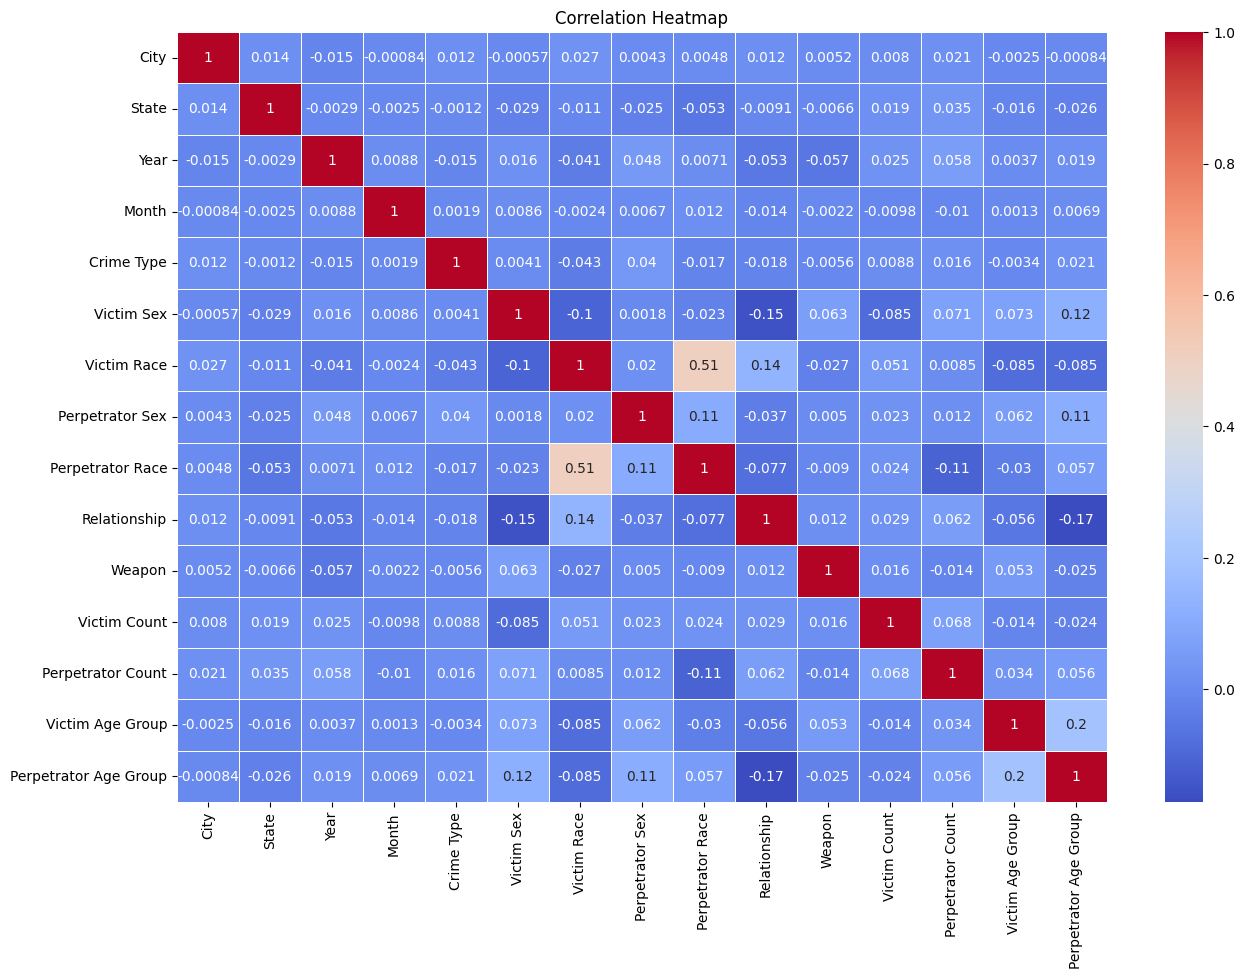

In [16]:
# Getting correlation matrix
correlation_matrix = homicide_data.corr()

# Plotting heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Model Building

In [17]:
# Select features
features = ['City', 'State', 'Year', 'Month', 'Crime Type', 'Victim Sex',
            'Victim Race', 'Perpetrator Sex', 'Perpetrator Race',
            'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count',
            'Victim Age Group', 'Perpetrator Age Group']

X = homicide_data[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

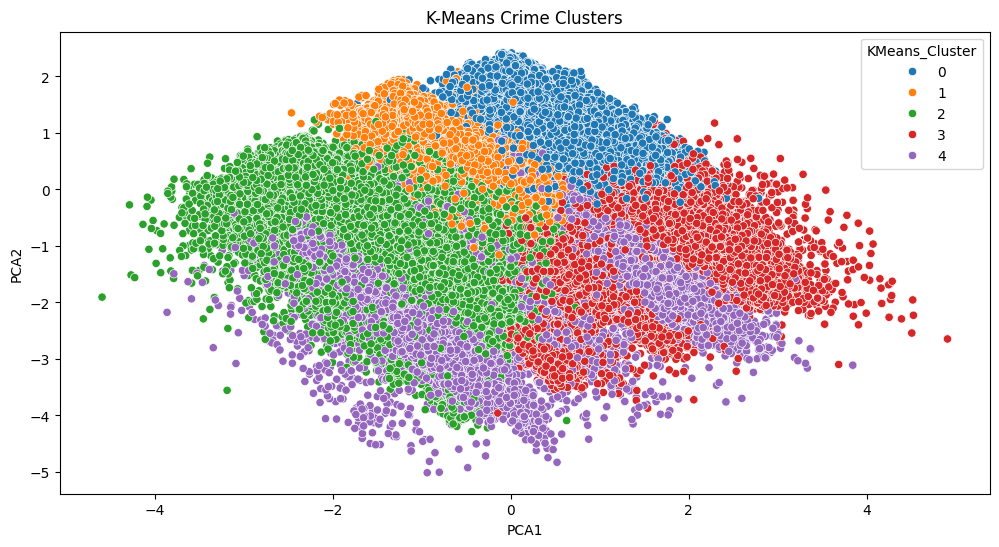

In [22]:
# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
homicide_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

In [23]:
# Mark clusters with high crime counts as serial crime clusters
serial_clusters = homicide_data['Cluster'].value_counts()
serial_clusters = serial_clusters[serial_clusters > 30].index.tolist()

# Create the target column
homicide_data['Serial_Crime'] = homicide_data['Cluster'].apply(lambda x: 1 if x in serial_clusters else 0)

In [24]:
# Use features and target
X = homicide_data[features]
y = homicide_data['Serial_Crime']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# Build KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on training data
y_train_pred = knn.predict(X_train)

# Predict on test data
y_test_pred = knn.predict(X_test)

# Accuracy report
print("\n🔹 Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\n🔹 Testing Accuracy:", accuracy_score(y_test, y_test_pred))

# Detailed classification report
print("\n🔹 Classification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=5)
homicide_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Crime Clusters')
plt.show()

In [ ]:
# Check cluster composition
for cluster in homicide_data['KMeans_Cluster'].unique():
    print(f"\nCluster {cluster} sample crimes:")
    print(homicide_data[homicide_data['KMeans_Cluster'] == cluster][features].head())